In [3]:
import cga_utils
import prompt_versions
%load_ext autoreload
%autoreload 2

In [8]:
from langchain.globals import set_llm_cache
from langchain_community.cache import SQLiteCache

set_llm_cache(SQLiteCache(database_path=".langchain.ollama38_26.db"))

In [9]:
from langchain_community.chat_models import ChatOllama
llm = ChatOllama(model="qwen3:4b", temperature = 0.0, top_p = 1, repeat_penalty=1, presence_penalty=0, frequency_penalty=0)  # vagy bármely más elérhető Ollama modell

In [10]:
import pandas as pd
messages = prompt_versions.prompt_versions['V26']
messages = [(a, t.replace('/no_think','')) for (a,t)  in messages]
messages[-1] = ( messages[-1][0],  messages[-1][1] + "/no_think" ) 



#problematic_qids = list(pd.read_csv('res/e37.csv').query('error_code == "selection_error" and calc_pattern == "(#+#)/#"')['qid'])
#df = pd.read_csv('res/e38_19.csv')
#problematic_qids = list(df[df["question"].str.contains("percentage change")]['qid'])

#res = cga_utils.execute_datset_predictions(llm, messages, problematic_qids)
res = cga_utils.execute_dataset_predictions(llm, messages)

1755510332.9452205


0it [00:00, ?it/s]

b2786c1a-37de-4120-b03c-32bf5c81f157
What was the change in the amount for Appliances in 2019 from 2018?[Error]unsupported operand type(s) for -: 'tuple' and 'tuple'
[Error]unsupported operand type(s) for -: 'tuple' and 'tuple'
 failure: [Error]unsupported operand type(s) for -: 'tuple' and 'tuple' good answer:  -94 
<< 680-774 || [] || [680.0, 774.0] || False >>
fe11f001-3bfe-4089-8108-412676f0a780
What was the percentage change in the amount for Appliances in 2019 from 2018?[Error]Appliances data not found for 2019 or 2018
[Error]Appliances data not found for 2019 or 2018
 failure: [Error]Appliances data not found for 2019 or 2018 good answer:  -12.14 
<< (680-774)/774 || [] || [680.0, 774.0, 774.0] || False >>
5103aed0-b4e8-4fae-bf78-e2c9f4ba84cf
What is the difference between the domestic and international discount rates as at September 30, 2019?[Error]No matching entries found in the value list.
[Error]No matching entries found in the value list.
 failure: [Error]No matching entri

KeyboardInterrupt: 

In [6]:
annotated_results = cga_utils.annotate_results(res)
#annotated_results.to_csv('res/Ollama_2_gemma3n_e4b_code_values_v11_m1.csv')
cga_utils.calc_overall_value_match(annotated_results)

0.772635814889336

In [7]:

cga_utils.calc_overall_em(annotated_results), cga_utils.calc_overall_em_alt(annotated_results)

(0.7022132796780685, 0.7022132796780685)

In [8]:
annotated_results.to_csv('res/e38_24.csv')

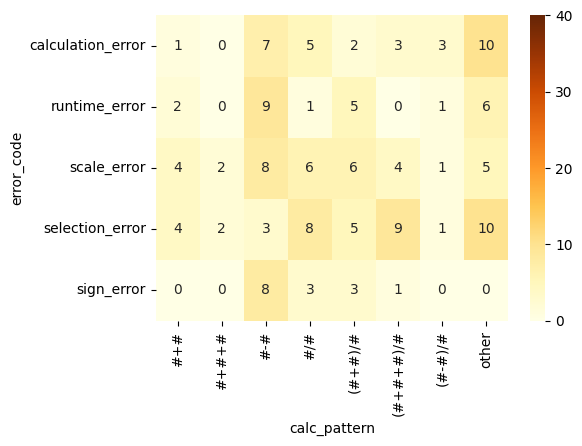

148

In [8]:
df = annotated_results.query('error_code != "none"')
cga_utils.crosstab_heatmap(df, 'error_code', 'calc_pattern', 40,0,3) 
len(df)

In [ ]:
set_llm_cache(SQLiteCache(database_path=".langchain.ollama38_x1.db"))
llm = ChatOllama(model="qwen3:4b", temperature = 0.0, top_p = 1, repeat_penalty=1, presence_penalty=0, frequency_penalty=0)  # vagy bármely más elérhető Ollama modell
res = cga_utils.execute_dataset_predictions(llm, messages)
annotated_results.to_csv('res/e38_22_x1.csv')
cga_utils.calc_overall_value_match(annotated_results), cga_utils.calc_overall_em(annotated_results), cga_utils.calc_overall_em_alt(annotated_results)

1755247533.5373132


0it [00:00, ?it/s]

b2786c1a-37de-4120-b03c-32bf5c81f157
What was the change in the amount for Appliances in 2019 from 2018? Success: -94.0
<< 680-774 || [680.0, 774.0, -94.0] || [680.0, 774.0] || True >>
fe11f001-3bfe-4089-8108-412676f0a780
What was the percentage change in the amount for Appliances in 2019 from 2018? Success: -12.14
<< (680-774)/774 || [680.0, 774.0, -12.144702842377262] || [680.0, 774.0, 774.0] || True >>
5103aed0-b4e8-4fae-bf78-e2c9f4ba84cf
What is the difference between the domestic and international discount rates as at September 30, 2019? Success: 2.1
<< 4.00 - 1.90  || [4.0, 1.9] || [4.0, 1.9] || True >>
4dc8be43-d8d9-4b08-9ffd-9c19012361ce
What is the year on year percentage change in domestic discount rate between 2018 and 2019? Success: 6.67
<< (4.00 - 3.75)/3.75  || [3.75, 4.0, 6.666666666666667] || [4.0, 3.75, 3.75] || True >>
6c44a1a8-0785-43a0-90ab-7e21df2c57d9
What is the year on year percentage change in international expected return on plan assets between 2018 and 2019? 